# Shor 9-Bit Quantum Error Correction Code

In [2]:
# Block 1: Dependencies and Environment Setup
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, state_fidelity, partial_trace
from qiskit.visualization import plot_state_city, plot_bloch_multivector
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit_aer.noise import NoiseModel
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_bloch_vector
# Initialize the simulator target with the physical device noise properties
backend = FakeFez()
sim_noise = AerSimulator.from_backend(backend)

noise = NoiseModel.from_backend(backend) 
sim_noise = AerSimulator(noise_model = noise)

## Circuit Register Definition and State Preparation

In [3]:
# Block 2: Circuit Initialization
q_data = QuantumRegister(9, name='data')
q_anc = QuantumRegister(8, name='ancilla')

# Classical registers for dynamic conditional tracking
c_b1 = ClassicalRegister(2, name='bit_syndrome_b1') # 2 bits to encode 3 possible error states (00, 01, 10) + 1 for no error (11) at each block
c_b2 = ClassicalRegister(2, name='bit_syndrome_b2')
c_b3 = ClassicalRegister(2, name='bit_syndrome_b3')
c_p = ClassicalRegister(2, name='phase_syndrome') # 2 bits for phase errors
c_data = ClassicalRegister(1, name='final_measurement')

circ = QuantumCircuit(q_data, q_anc, c_b1, c_b2, c_b3, c_p, c_data)

# Define the exact target ideal state: |ψ> = (√3/2)|0> + (1/2)|1>
theta = np.pi / 3
circ.ry(theta, q_data[0])
circ.barrier()

# Block 3: Encoding Phase
# 1. Outer Phase-Flip Encoding
circ.cx(q_data[0], q_data[3])
circ.cx(q_data[0], q_data[6])
circ.h(q_data[0])
circ.h(q_data[3])
circ.h(q_data[6])
circ.barrier()

# 2. Inner Bit-Flip Encoding
# Block 1 (Qubits 0, 1, 2)
circ.cx(q_data[0], q_data[1])
circ.cx(q_data[0], q_data[2])
# Block 2 (Qubits 3, 4, 5)
circ.cx(q_data[3], q_data[4])
circ.cx(q_data[3], q_data[5])
# Block 3 (Qubits 6, 7, 8)
circ.cx(q_data[6], q_data[7])
circ.cx(q_data[6], q_data[8])
circ.barrier()

# Block 4: Error Sandbox
# Example: Injecting a bit-flip on qubit 1 and a phase-flip on qubit 3
circ.y(q_data[0])
# circ.z(q_data[3])
circ.barrier()


# 1. Bit-Flip Syndrome Extraction (Z-stabilizers)
# Block 1: Z0Z1 and Z1Z2
circ.cx(q_data[0], q_anc[0])
circ.cx(q_data[1], q_anc[0])
circ.cx(q_data[1], q_anc[1])
circ.cx(q_data[2], q_anc[1])

# Block 2: Z3Z4 and Z4Z5
circ.cx(q_data[3], q_anc[2])
circ.cx(q_data[4], q_anc[2])
circ.cx(q_data[4], q_anc[3])
circ.cx(q_data[5], q_anc[3])

# Block 3: Z6Z7 and Z7Z8
circ.cx(q_data[6], q_anc[4])
circ.cx(q_data[7], q_anc[4])
circ.cx(q_data[7], q_anc[5])
circ.cx(q_data[8], q_anc[5])

# 2. Phase-Flip Syndrome Extraction (X-stabilizers via H gates)
circ.h(q_anc[6])
circ.h(q_anc[7])

# X0X1X2X3X4X5 stabilizer
for i in range(6):
    circ.cx(q_anc[6], q_data[i])
# X3X4X5X6X7X8 stabilizer
for j in range(3, 9):
    circ.cx(q_anc[7], q_data[j])

circ.h(q_anc[6])
circ.h(q_anc[7])
circ.barrier()

# Measure all ancilla registers
circ.measure([q_anc[0], q_anc[1]], c_b1)
circ.measure([q_anc[2], q_anc[3]], c_b2)
circ.measure([q_anc[4], q_anc[5]], c_b3)
circ.measure([q_anc[6], q_anc[7]], c_p)
circ.barrier()



# Block 6: Dynamic Correction and Post-Correction Snapshot
# Bit-Flip Conditional Corrections
with circ.if_test((c_b1, 1)): circ.x(q_data[0])
with circ.if_test((c_b1, 3)): circ.x(q_data[1]) 
with circ.if_test((c_b1, 2)): circ.x(q_data[2])

with circ.if_test((c_b2, 1)): circ.x(q_data[3])
with circ.if_test((c_b2, 3)): circ.x(q_data[4])
with circ.if_test((c_b2, 2)): circ.x(q_data[5])

with circ.if_test((c_b3, 1)): circ.x(q_data[6])
with circ.if_test((c_b3, 3)): circ.x(q_data[7])
with circ.if_test((c_b3, 2)): circ.x(q_data[8])

# Phase-Flip Conditional Corrections
with circ.if_test((c_p, 1)): circ.z(q_data[0])
with circ.if_test((c_p, 3)): circ.z(q_data[3])
with circ.if_test((c_p, 2)): circ.z(q_data[6])

# Block 6.5: Decoding Phase (Reverse of Encoding)
# Este bloque concentra la información lógica de nuevo en el q_data[0]
circ.barrier()

# 1. Reverse Inner Bit-Flip Encoding
# Block 3
circ.cx(q_data[6], q_data[8])
circ.cx(q_data[6], q_data[7])
# Block 2
circ.cx(q_data[3], q_data[5])
circ.cx(q_data[3], q_data[4])
# Block 1
circ.cx(q_data[0], q_data[2])
circ.cx(q_data[0], q_data[1])
circ.barrier()

# 2. Reverse Outer Phase-Flip Encoding
circ.h(q_data[0])
circ.h(q_data[3])
circ.h(q_data[6])

circ.cx(q_data[0], q_data[6])
circ.cx(q_data[0], q_data[3])
circ.barrier()


circ.barrier()

# Final logical readout
circ.measure(q_data[0], c_data)

## Tomography for Z component at ideal model

In [4]:
sim_ideal = AerSimulator()
circ_z = circ.copy()
# 2. Transpile and execute the base circuit (Z-basis)
circ_ideal_z_transpiled = transpile(circ_z, sim_ideal)
result_ideal_z = sim_ideal.run(circ_ideal_z_transpiled, shots=8192).result()
counts_ideal_z_full = result_ideal_z.get_counts(circ_ideal_z_transpiled)

# 3. Parse the counts to isolate the data qubit (index 0)
counts_z_data_ideal = {'0': 0, '1': 0}
for state, count in counts_ideal_z_full.items():
    data_bit = state.split()[0]
    counts_z_data_ideal[data_bit] += count

print("Ideal Isolated Data Qubit Results (Z-basis):", counts_z_data_ideal)

# 4. Display the clean histogram
fig1 = plot_histogram(counts_z_data_ideal, title='Tomography for Z component at ideal model for Shor code')
fig1.savefig('Tomography_comp_Z_shor.png')

Ideal Isolated Data Qubit Results (Z-basis): {'0': 6102, '1': 2090}


## Tomography for Z component at noisy model

In [5]:
circ_z_noise = circ.copy()
circ_z_noise_transpiled = transpile(circ_z_noise, sim_noise)
result_noise_z = sim_noise.run(circ_z_noise_transpiled, shots=8192).result()
counts_noise_z_full = result_noise_z.get_counts(circ_z_noise_transpiled)

# The counts string format is: 'c_data c_p c_b3 c_b2 c_b1' (e.g., '0 00 00 00 00')
# We parse the dictionary to isolate only the measurement of the data qubit
counts_z_data_noise = {'0': 0, '1': 0}
for state, count in counts_noise_z_full.items():
    data_bit = state.split()[0]
    counts_z_data_noise[data_bit] += count

print("Isolated Data Qubit Results:", counts_z_data_noise)

# Display the clean histogram keeping technical labels
fig2 = plot_histogram(counts_z_data_noise, title='Tomography for Z component at noisy model for Shor code')
fig2.savefig('Tomography_comp_Z_shor_noisy.png')

Isolated Data Qubit Results: {'0': 5822, '1': 2370}


## Tomography for X component at ideal model

In [13]:
# Block 13: Tomography for X component at ideal model
# 1. Transpile and execute the X-basis circuit
sim_ideal = AerSimulator()
circ_x_ideal = circ.copy()
del circ_x_ideal.data[-1] 

# 2. Build the X-basis measurement circuit
circ_x_ideal = circ_x_ideal.copy()
circ_x_ideal.h(q_data[0])  # Rotate to X-basis
circ_x_ideal.measure(q_data[0], c_data)


circ_ideal_x_transpiled = transpile(circ_x_ideal, sim_ideal)
result_ideal_x = sim_ideal.run(circ_ideal_x_transpiled, shots=8192).result()
counts_ideal_x_full = result_ideal_x.get_counts(circ_ideal_x_transpiled)

# 2. Parse the counts to isolate the data qubit
counts_x_data_ideal = {'0': 0, '1': 0}
for state, count in counts_ideal_x_full.items():
    data_bit = state.split()[0]
    counts_x_data_ideal[data_bit] += count

print("Ideal Isolated Data Qubit Results (X-basis):", counts_x_data_ideal)

# 3. Display the clean histogram
fig3 = plot_histogram(counts_x_data_ideal, title='Tomography for X component at ideal model for Shor code')
fig3.savefig('Tomography_comp_X_shor.png')

Ideal Isolated Data Qubit Results (X-basis): {'0': 7596, '1': 596}


## Tomography for X component at noisy model

In [7]:

circ_x_noise = circ.copy()
del circ_x_noise.data[-1] 

# 2. Build the X-basis measurement circuit
circ_x_noise = circ_x_noise.copy()
circ_x_noise.h(q_data[0])  # Rotate to X-basis
circ_x_noise.measure(q_data[0], c_data)

# 3. Transpile and execute on the noisy device simulator
circ_x_noise_transpiled = transpile(circ_x_noise, sim_noise)
result_noise_x = sim_noise.run(circ_x_noise_transpiled, shots=8192).result()
counts_noise_x_noise_full = result_noise_x.get_counts(circ_x_noise_transpiled)

# 4. Parse the counts to isolate the data qubit
counts_x_data_noise = {'0': 0, '1': 0}
for state, count in counts_noise_x_noise_full.items():
    data_bit = state.split()[0]
    counts_x_data_noise[data_bit] += count

print("Isolated Data Qubit Results (X-basis):", counts_x_data_noise)

# 5. Visualizing the X component histogram
fig4 = plot_histogram(counts_x_data_noise, title='Tomography for X component at noisy model for Shor code')
fig4.savefig('Tomography_comp_X_shor_noisy.png')

Isolated Data Qubit Results (X-basis): {'0': 7100, '1': 1092}


## Tomography for Y component at ideal model

In [8]:
# Block 14: Tomography for Y component at ideal model
# 1. Transpile and execute the Y-basis circuit
circ_y = circ.copy()
circ_y.h(q_data[0])  # Rotate to Y-basis
circ_y.s(q_data[0])  # Apply S gate
circ_y.measure(q_data[0], c_data)

circ_ideal_y_transpiled = transpile(circ_y, sim_ideal)
result_ideal_y = sim_ideal.run(circ_ideal_y_transpiled, shots=8192).result()
counts_ideal_y_full = result_ideal_y.get_counts(circ_ideal_y_transpiled)

# 2. Parse the counts to isolate the data qubit
counts_y_data_ideal = {'0': 0, '1': 0}
for state, count in counts_ideal_y_full.items():
    data_bit = state.split()[0]
    counts_y_data_ideal[data_bit] += count

print("Ideal Isolated Data Qubit Results (Y-basis):", counts_y_data_ideal)

# 3. Display the clean histogram
fig5 = plot_histogram(counts_y_data_ideal, title='Tomography for Y component at ideal model for Shor code')
fig5.savefig('Tomography_comp_Y_shor.png')

Ideal Isolated Data Qubit Results (Y-basis): {'0': 4082, '1': 4110}


## Tomography for Y component at noisy model

In [9]:
circ_y_noise = circ.copy()
circ_y_noise.sdg(q_data[0])  # Apply S-dagger
circ_y_noise.h(q_data[0])    # Apply Hadamard to complete the Y-basis rotation
circ_y_noise.measure(q_data[0], c_data)

# 2. Transpile and execute on the noisy device simulator
circ_y_noise_transpiled = transpile(circ_y_noise, sim_noise)
result_noise_y = sim_noise.run(circ_y_noise_transpiled, shots=8192).result()
counts_noise_y_full = result_noise_y.get_counts(circ_y_noise_transpiled)

# 3. Parse the counts to isolate the data qubit
counts_y_data_noise = {'0': 0, '1': 0}
for state, count in counts_noise_y_full.items():
    data_bit = state.split()[0]
    counts_y_data_noise[data_bit] += count

print("Isolated Data Qubit Results (Y-basis):", counts_y_data_noise)

# 4. Visualizing the Y component histogram
fig6 = plot_histogram(counts_y_data_noise, title='Tomography for Y component at noisy model for Shor code')
fig6.savefig('Tomography_comp_Y_shor_noisy.png')

Isolated Data Qubit Results (Y-basis): {'0': 4166, '1': 4026}


Top 10 most frequent states: {'0 01 00 00 01': 5223, '1 01 00 00 01': 1875, '1 00 00 00 01': 171, '0 01 00 10 01': 150, '1 11 00 00 01': 112, '0 00 00 00 01': 101, '0 01 01 00 01': 64, '1 01 00 10 01': 54, '0 01 00 00 00': 47, '0 01 00 01 01': 47}


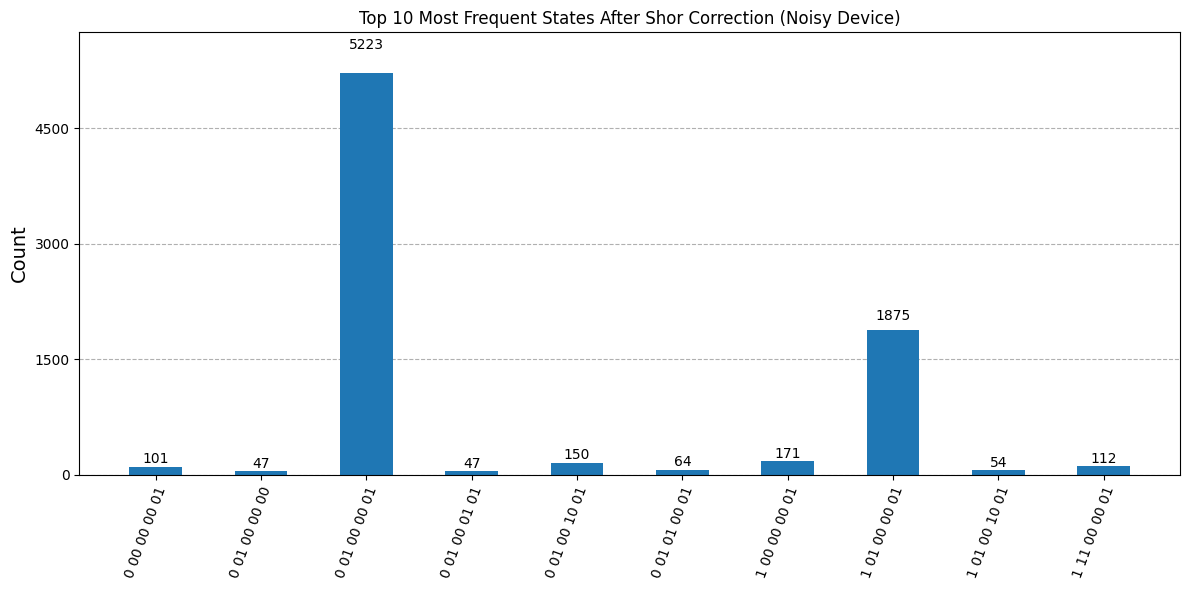

In [10]:
# Block 15: Noise Profile Analysis (Top N Frequent Outcomes)
from qiskit.visualization import plot_histogram

# We use the raw counts from the noisy Z-basis execution
# Structure: 'c_data c_p c_b3 c_b2 c_b1' (e.g., '0 00 00 00 00')
raw_noisy_counts = counts_noise_z_full

# Sort the dictionary by observation frequency in descending order
sorted_counts = dict(sorted(raw_noisy_counts.items(), key=lambda item: item[1], reverse=True))

# Extract only the top 10 most frequent states to keep the plot readable
top_10_counts = {k: sorted_counts[k] for k in list(sorted_counts)[:10]}

print("Top 10 most frequent states:", top_10_counts)

# Generate the plot with a larger figure size to accommodate the long string labels
plot_histogram(
    top_10_counts, 
    title='Top 10 Most Frequent States After Shor Correction (Noisy Device)',
    figsize=(12, 6)
)

# Fidelity calculation for ideal simulation

In [14]:
# Direct extraction and calculation for the Z component
shots = 8192
counts_0_z_ideal = sum(val for key, val in counts_z_data_ideal.items() if key.startswith('0'))
counts_1_z_ideal = sum(val for key, val in counts_z_data_ideal.items() if key.startswith('1'))
mean_z_ideal = (counts_0_z_ideal - counts_1_z_ideal) / shots


# Direct extraction and calculation for the X component

counts_0_x_ideal = sum(val for key, val in counts_x_data_ideal.items() if key.startswith('0'))
counts_1_x_ideal = sum(val for key, val in counts_x_data_ideal.items() if key.startswith('1'))
mean_x_ideal = (counts_0_x_ideal - counts_1_x_ideal) / shots


# Direct extraction and calculation for the Y component

counts_0_y_ideal = sum(val for key, val in counts_y_data_ideal.items() if key.startswith('0'))
counts_1_y_ideal = sum(val for key, val in counts_y_data_ideal.items() if key.startswith('1'))
mean_y_ideal = (counts_0_y_ideal - counts_1_y_ideal) / shots

# Print the results
print(f"Mean value for Z component: {mean_z_ideal}")
print(f"Mean value for X component: {mean_x_ideal}")
print(f"Mean value for Y component: {mean_y_ideal}")

# Verify probability conservation
prob = mean_x_ideal ** 2 + mean_y_ideal ** 2 + mean_z_ideal ** 2
print(f"Probability conservation (should be close to 1.0): {prob}")

# Plot the Bloch vector
vector = np.array([mean_x_ideal, mean_y_ideal, mean_z_ideal])
plot_bloch_vector(vector, title='Bloch vector for the corrected state')


# Density matrix reconstruction from the measured Bloch vector components
rho_reconstructed = 0.5 * (
    np.eye(2) +
    mean_x_ideal * np.array([[0,1],[1,0]]) +
    mean_y_ideal * np.array([[0,-1j],[1j,0]]) +
    mean_z_ideal * np.array([[1,0],[0,-1]])
)

# Ideal state as a density matrix vector
ideal = np.array([np.sqrt(3)/2, 1/2])
rho_ideal = np.outer(ideal, ideal)

# Fidelity F = Tr(rho_ideal @ rho_reconstructed)
# For pure state: F = <psi|rho|psi>
fidelity = np.real(np.trace(rho_ideal @ rho_reconstructed))
print(f"Fidelity reconstructed: {fidelity:.6f}")

Mean value for Z component: 0.48974609375
Mean value for X component: 0.8544921875
Mean value for Y component: -0.00341796875
Probability conservation (should be close to 1.0): 0.9700198173522949
Fidelity reconstructed: 0.992442


# Fidelity calculation for noisy simulation

In [12]:
# Direct extraction and calculation for the Z component

counts_0_noise_z = sum(val for key, val in counts_z_data_noise.items() if key.startswith('0'))
counts_1_noise_z = sum(val for key, val in counts_z_data_noise.items() if key.startswith('1'))
mean_noise_z = (counts_0_noise_z - counts_1_noise_z) / shots


# Direct extraction and calculation for the X component

counts_0_noise_x = sum(val for key, val in counts_x_data_noise.items() if key.startswith('0'))
counts_1_noise_x = sum(val for key, val in counts_x_data_noise.items() if key.startswith('1'))
mean_noise_x = (counts_0_noise_x - counts_1_noise_x) / shots


# Direct extraction and calculation for the Y component

counts_0_noise_y = sum(val for key, val in counts_y_data_noise.items() if key.startswith('0'))
counts_1_noise_y = sum(val for key, val in counts_y_data_noise.items() if key.startswith('1'))
mean_noise_y = (counts_0_noise_y - counts_1_noise_y) / shots

# Print the results
print(f"Mean value for Z component: {mean_noise_z}")
print(f"Mean value for X component: {mean_noise_x}")
print(f"Mean value for Y component: {mean_noise_y}")

# Verify probability conservation
prob = mean_noise_x ** 2 + mean_noise_y ** 2 + mean_noise_z ** 2
print(f"Probability conservation (should be close to 1.0): {prob}")

# Plot the Bloch vector
vector = np.array([mean_noise_x, mean_noise_y, mean_noise_z])
plot_bloch_vector(vector, title='Bloch vector for the corrected state')


# Density matrix reconstruction from the measured Bloch vector components
rho_reconstructed = 0.5 * (
    np.eye(2) +
    mean_noise_x * np.array([[0,1],[1,0]]) +
    mean_noise_y * np.array([[0,-1j],[1j,0]]) +
    mean_noise_z * np.array([[1,0],[0,-1]])
)

# Ideal state as a density matrix vector
ideal = np.array([np.sqrt(3)/2, 1/2])
rho_ideal = np.outer(ideal, ideal)

# Fidelity F = Tr(rho_ideal @ rho_reconstructed)
# For pure state: F = <psi|rho|psi>
fidelity = np.real(np.trace(rho_ideal @ rho_reconstructed))
print(f"Fidelity reconstructed: {fidelity:.6f}")

Mean value for Z component: 0.42138671875
Mean value for X component: 0.7333984375
Mean value for Y component: 0.01708984375
Probability conservation (should be close to 1.0): 0.7157320976257324
Fidelity reconstructed: 0.922918
